# **AI-Powered Workforce Analytics & Talent Intelligence Dashboard**

## **Data Cleaning and Exploratory Data Analysis (EDA)**
### Infosys Springboard Virtual Internship

**Project Module:** Data Cleaning & Exploratory Data Analysis

**Team Role:** Data Cleaning, Data Quality Assessment, Feature Analysis and Exploratory Data Analysis

______________________________________________________________________________
### Project Objective

The objective of this notebook is to prepare workforce data for AI-driven workforce analytics by performing data cleaning, data quality assessment, exploratory data analysis (EDA), feature relationship analysis, and generating insights that support employee attrition prediction and workforce intelligence.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import Libraries and Load Dataset

The required Python libraries are imported for data manipulation, visualization, and analysis. The workforce dataset is then loaded from Google Drive for further preprocessing and analysis.

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load dataset
df = pd.read_csv("/content/drive/MyDrive/Workforce_Analytics_Dashboard/DATASET.csv")

In [ ]:
df_original = df.copy()

## 2. Dataset Preview

The first few records of the dataset are displayed to understand the available workforce attributes and verify that the dataset has been loaded successfully.

In [ ]:
#display first few records of the dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


The dataset contains **employee-related information** such as Age, Department, Job Role, Monthly Income, working hours, Overtime, Satisfaction, and Attrition.

## Dataset Information

The dataset information provides details about the number of records, feature names, data types, and memory usage. This helps verify the structure of the dataset before preprocessing.

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

The dataset contains 1470 rows and 35 columns. There are 26 columns are of integer datatype and 9 columns are of object.There is no null values present in the dataset.

## Statistical Summary

Descriptive statistics are generated to understand the central tendency, spread, and distribution of numerical workforce attributes.

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# 3. Data Cleaning

Data cleaning is performed to improve data quality before analysis and machine learning. The process includes checking data types, missing values, duplicate records, invalid values, inconsistent categories, unnecessary columns, and outliers.

In [ ]:
#check data types
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
#Check inconsistent categorical values
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].unique())
    print("-"*40)

Attrition
['Yes' 'No']
----------------------------------------
BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
----------------------------------------
Department
['Sales' 'Research & Development' 'Human Resources']
----------------------------------------
EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
----------------------------------------
Gender
['Female' 'Male']
----------------------------------------
JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
----------------------------------------
MaritalStatus
['Single' 'Married' 'Divorced']
----------------------------------------
Over18
['Y']
----------------------------------------
OverTime
['Yes' 'No']
----------------------------------------


Inconsistent values are not found.

In [ ]:
# check for missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


No missing values were present in the dataset.


In [ ]:
#check for duplicate data
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.


In [ ]:
#find unique values
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


Columns like Employee_count,Over18, and StandardHours has only one unique value.

Remove Unnecessary Columns

EmployeeCount, Over18, StandardHours, EmployeeNumber columns contain constant values or unique identifiers that are not useful for analysis.So we remove this columns because they do not provide meaningful information for analysis.

In [ ]:
#remove unnecessary columns
df.drop(columns=["EmployeeCount","Over18","StandardHours"],inplace=True)

In [ ]:
df.shape

(1470, 32)

In [ ]:
#Check for invalid values
df[df["Age"] < 18]
df[df["MonthlyIncome"] < 0]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


No invalid values are found.


# **Detect Outliers**
Identify extreme values (outliers) in numerical columns that may affect data analysis and machine learning model performance.
Outliers are unusually high or low values compared to the rest of the data. They can:

Influence statistical measures such as the mean.
Affect visualization results.
Reduce the performance of machine learning models.
Represent data entry errors or genuine extreme observations.

Therefore, detecting outliers helps us understand the data better and decide whether they should be retained or treated.

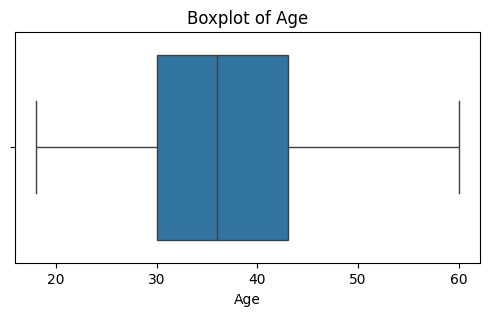

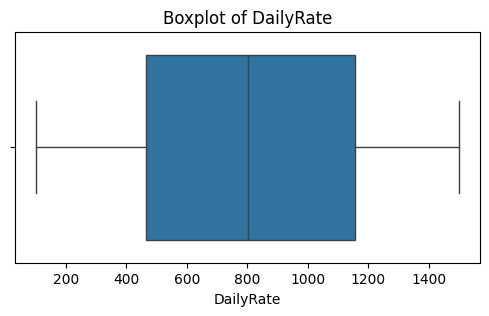

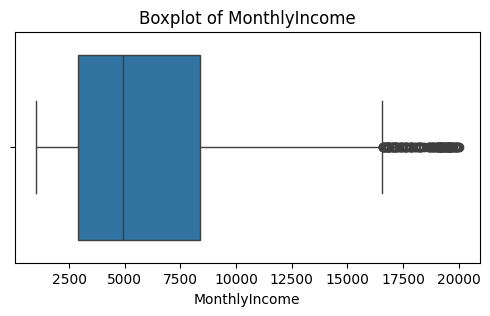

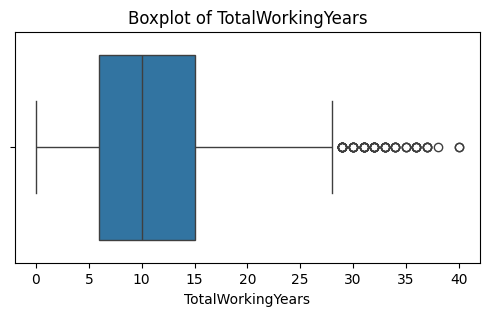

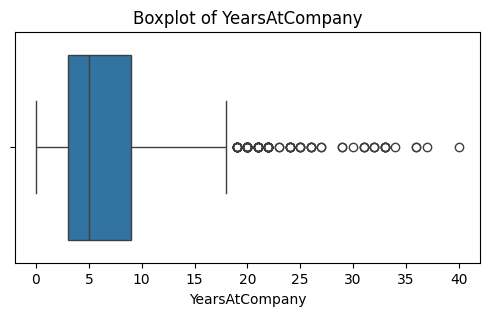

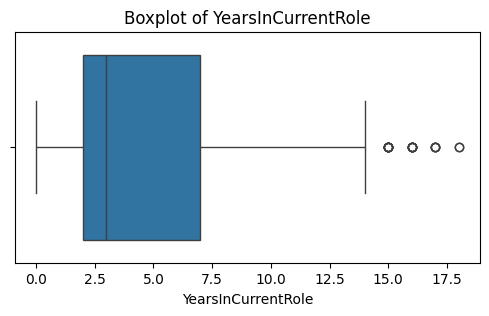

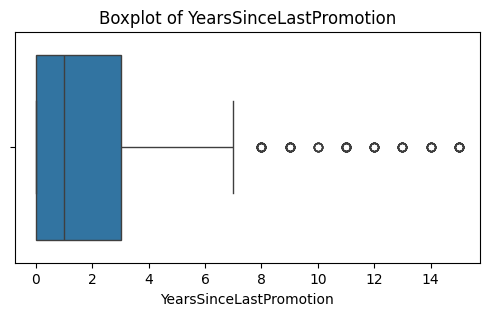

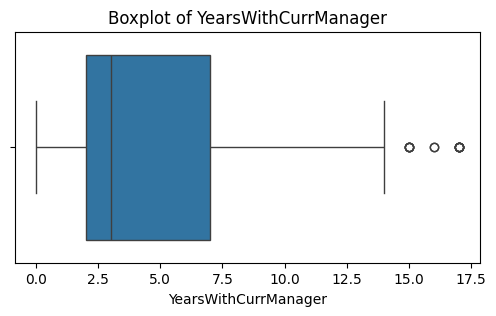

In [ ]:
columns = ["Age", "DailyRate", "MonthlyIncome",
           "TotalWorkingYears", "YearsAtCompany","YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"]

for col in columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Observation**

After plotting the boxplots:

Age: Few or no significant outliers

DailyRate: No major outliers.

MonthlyIncome: Several high-income values appear as outliers.

TotalWorkingYears: Some employees have considerably more experience than others.

YearsAtCompany: A few employees have worked much longer than the majority.

YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager have very few outliers.

These values are expected in an employee dataset and may represent senior or highly experienced employees rather than incorrect data.

# **Outlier Treatment**
Outliers can distort statistical measures and affect machine learning model performance. Instead of removing employee records, extreme values are capped using the IQR method.


In [ ]:
#IQR Capping for treating the outliers
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Cap the outliers
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers treated successfully.")

Outliers treated successfully.


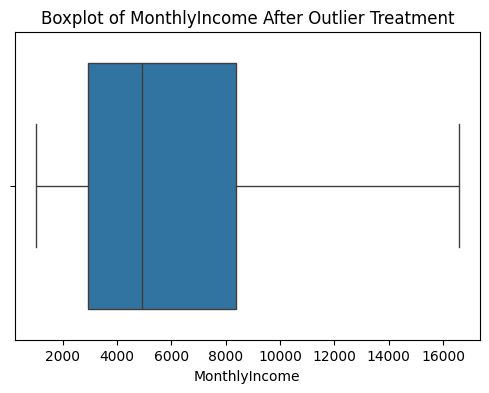

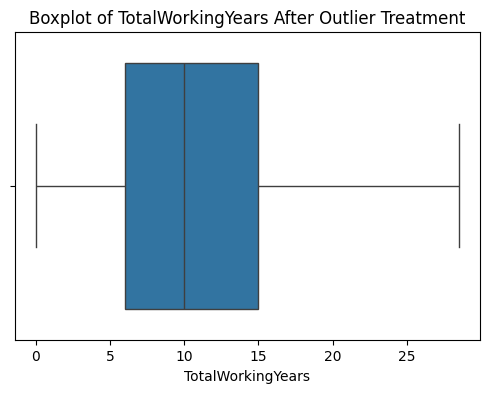

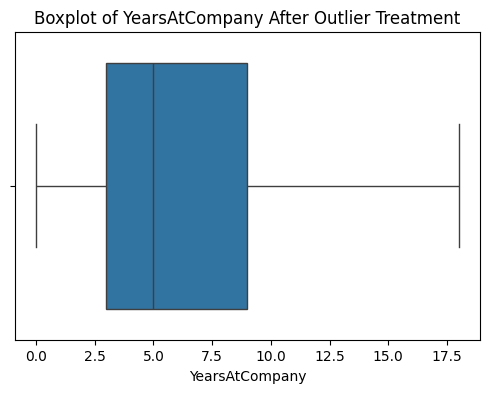

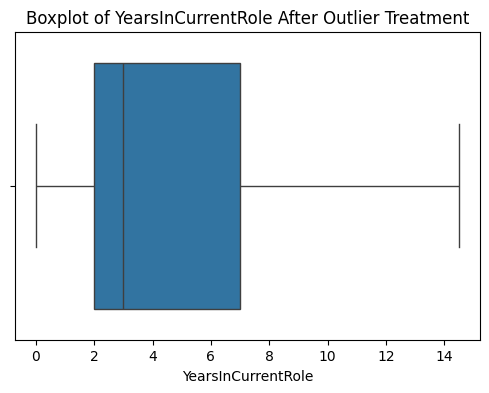

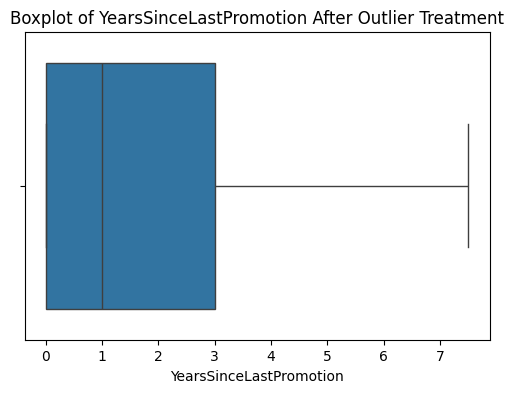

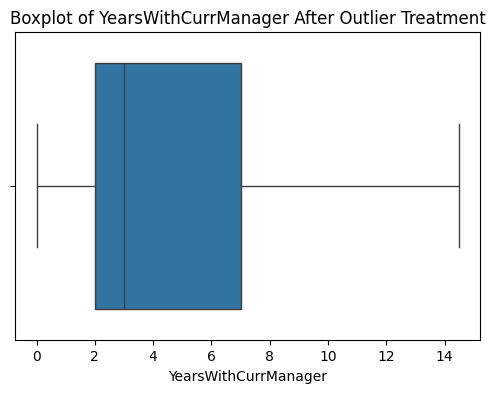

In [ ]:
#verify the result
import matplotlib.pyplot as plt
import seaborn as sns

outlier_cols = [
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

for col in outlier_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col} After Outlier Treatment")
    plt.xlabel(col)
    plt.show()

The extreme values have been capped within the acceptable IQR range. This reduces the influence of outliers while keeping all employee records in the dataset.
Outliers were treated using the IQR capping method. This approach preserves all records and minimizes the effect of extreme values on analysis.


# **4. Save the clean dataset.**

In [ ]:
df.to_csv("/content/drive/MyDrive/Workforce_Analytics_Dashboard/cleaned_attrition_dataset.csv",index=False)

# **Data Quality Assessment**
The dataset was assessed during the Data Cleaning phase.

The following activities were completed:

- Missing value analysis
- Duplicate record verification
- Data type validation
- Constant column removal
- Identifier column removal
- Outlier detection
- Outlier treatment using IQR capping

The cleaned dataset was used for all subsequent exploratory analysis.

# **5. Exploratory Data Analysis (EDA)**

## Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the cleaned workforce dataset, identify trends and patterns, analyze relationships among employee attributes, and generate business insights that support workforce analytics, talent intelligence, and predictive modeling.

**Summary Statistics**

Obtain descriptive statistics to understand the distribution of numerical and categorical variables.

In [ ]:
# Summary statistics for numerical features
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.0,2.712245,0.764966,11.103061,2.710884,2.761224,6.617687,4.207823,1.922789,4.107483
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.0,1.081209,0.782312,7.303828,1.037954,0.706476,4.989788,3.555335,2.478222,3.517487
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.0,1.000000,0.000000,0.000000,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.0,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.0,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.0,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,3.0,4.000000,2.500000,28.500000,4.500000,4.000000,18.000000,14.500000,7.500000,14.500000


In [ ]:
# Summary statistics for categorical features
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,No
freq,1233,1043,961,606,882,326,673,1054


**Observation**

The dataset contains employee demographic and organizational information.
Numerical features such as Age, MonthlyIncome, and TotalWorkingYears show varying distributions.
Categorical variables include Department, JobRole, Gender, BusinessTravel, and Attrition.

# **Feature Relationships (Univariate Analysis)**
Univariate Analysis is performed to analyze one variable at a time. It helps understand the distribution, frequency, and characteristics of individual employee attributes within the workforce dataset.

# **5.1 Analyze Target Variable (Attrition)**

Analyze the distribution of employees who stayed and those who left the organization.

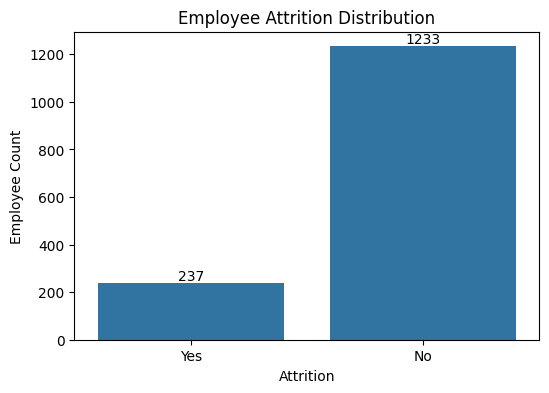

In [ ]:
#Employee Attrition Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Attrition', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")

plt.show()

In [ ]:
(df["Attrition"].value_counts(normalize=True) * 100).round(2)

,proportion
Attrition,
No,83.88
Yes,16.12


**Observation**

- Out of 1,470 employees, **1,233 employees (83.88%)** remained with the organization, while **237 employees (16.12%)** left.
- The dataset is **imbalanced**, as the number of employees who stayed is significantly higher than those who left.
- Employee retention appears to be strong, with the majority of the workforce continuing their employment.

**Business Insight**

Employee attrition is the primary target variable in this project. Understanding its distribution helps HR teams monitor employee retention and supports the development of predictive models to identify employees who may be at risk of leaving the organization. Since the dataset is imbalanced, appropriate evaluation metrics or balancing techniques may be considered during the machine learning phase.

**Conclusion**

The organization demonstrates a relatively high employee retention rate, with approximately 84% of employees remaining in the company. However, the 16% attrition rate indicates opportunities to improve retention strategies, which will be explored further through relationship analysis between attrition and other workforce factors.

# **5.2 Age Distribution**
To analyze the distribution of employee ages within the organization and identify the predominant age groups in the workforce.

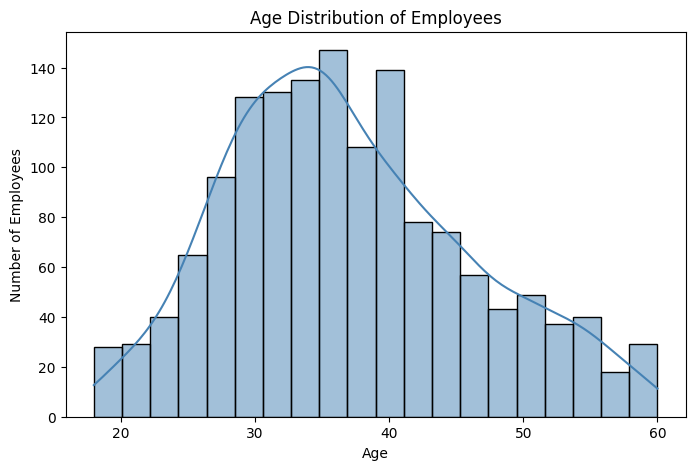

,Age
count,1470.000000
mean,36.923810
std,9.135373
min,18.000000
25%,30.000000
50%,36.000000
75%,43.000000
max,60.000000


In [ ]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,
    color='steelblue'
)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

df["Age"].describe()

**Observation**

- The employee age ranges from approximately **18 to 60 years**.
- Most employees fall within the **30–40 years** age group, indicating that the organization has a predominantly mid-career workforce.
- The distribution is **slightly right-skewed**, with fewer employees in the higher age groups (above 50 years).
- Very few employees are younger than 25 years or older than 55 years.

**Business Insight**

The workforce is primarily composed of employees in their early and mid-career stages. This indicates a stable and experienced employee base, which can support organizational growth. HR can use this information for succession planning, leadership development, and targeted recruitment strategies for younger talent.

**Conclusion**

The age distribution suggests that the organization has a balanced workforce with a strong concentration of experienced employees. Understanding this demographic profile helps HR design age-specific engagement, learning, and career development initiatives.

In [ ]:
print(f"Average Age : {df['Age'].mean():.2f}")
print(f"Median Age  : {df['Age'].median()}")
print(f"Minimum Age : {df['Age'].min()}")
print(f"Maximum Age : {df['Age'].max()}")

Average Age : 36.92
Median Age  : 36.0
Minimum Age : 18
Maximum Age : 60


# **5.3 Gender Distribution**

**Objective**

To analyze the gender composition of employees within the organization and understand workforce diversity.

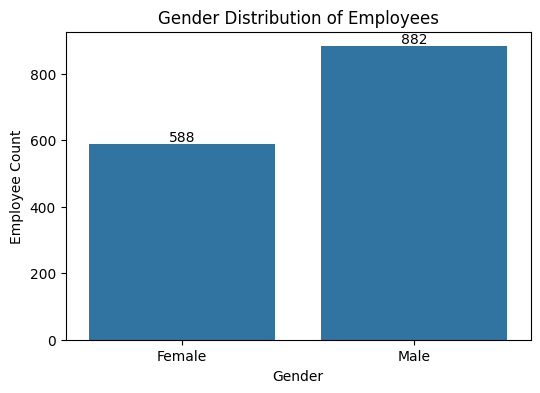

,count
Gender,
Male,882
Female,588


In [ ]:
#Gender Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Gender',
    data=df
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution of Employees")
plt.xlabel("Gender")
plt.ylabel("Employee Count")

plt.show()

df["Gender"].value_counts()

In [ ]:
#percentage
gender_percentage = (df["Gender"].value_counts(normalize=True) * 100).round(2)
print(gender_percentage)

Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64


**Observation**

- The workforce consists of **882 male employees (60%)** and **588 female employees (40%)**.
- Male employees represent the majority of the workforce.
- Female employees also have a significant presence, indicating participation from both genders across the organization.

**Business Insight**

Gender distribution is an important workforce diversity metric. The organization has representation from both male and female employees, which supports Diversity, Equity, and Inclusion (DEI) initiatives. HR can further analyze gender representation across departments and job roles to identify opportunities for improving workforce diversity.

**Conclusion**

The organization maintains a workforce with representation from both genders, although male employees constitute a larger proportion. Monitoring gender distribution helps organizations evaluate diversity initiatives and support inclusive workforce planning.

# **5.4 Department-wise Employee Distribution**

Objective

To analyze the distribution of employees across different organizational departments and identify the departments with the highest workforce representation.

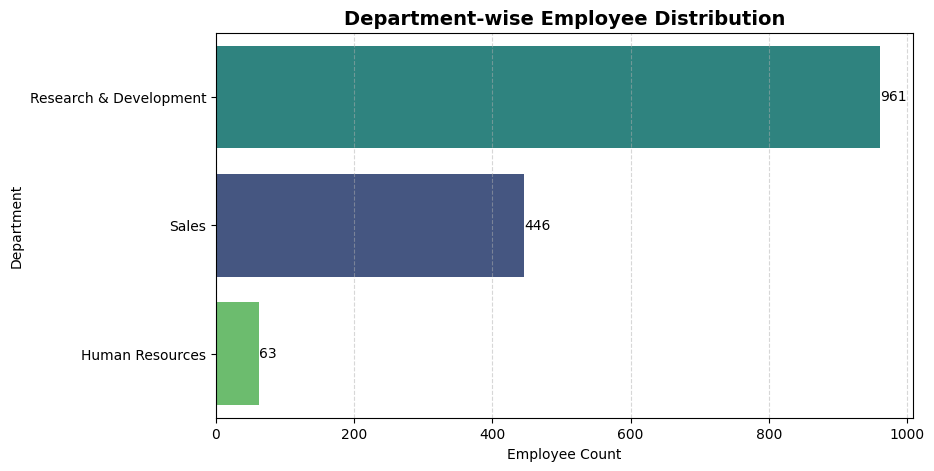

Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64


In [ ]:
#Identify the distribution of employees across departments.
plt.figure(figsize=(9,5))

ax = sns.countplot(
    y='Department',
    data=df,
    order=df['Department'].value_counts().index,
    hue='Department',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Department-wise Employee Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Employee Count")
plt.ylabel("Department")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

#percentage
department_percentage = (df["Department"].value_counts(normalize=True) * 100).round(2)
print(department_percentage)

**Observation**

- The organization has employees distributed across three departments: Research & Development, Sales, and Human Resources.
- The **Research & Development** department has the highest workforce with **961 employees (65.37%)**.
- The **Sales** department consists of **446 employees (30.34%)**.
- The **Human Resources** department has the smallest workforce with **63 employees (4.29%)**.

**Business Insight**

The workforce is primarily concentrated in the Research & Development department, indicating that the organization's core operations are focused on innovation and product development. Understanding department-wise employee distribution helps HR optimize workforce planning, resource allocation, recruitment strategies, and departmental budgeting.

**Conclusion**

The analysis shows that the majority of employees work in the Research & Development department, followed by Sales and Human Resources. These insights provide a foundation for further analysis of department-wise attrition, employee engagement, and workforce planning.


#**5.6 Job Role Distribution**

**Objective**

To analyze the distribution of employees across different job roles and identify the roles with the highest workforce representation. This analysis helps understand workforce composition and supports talent management and resource planning.


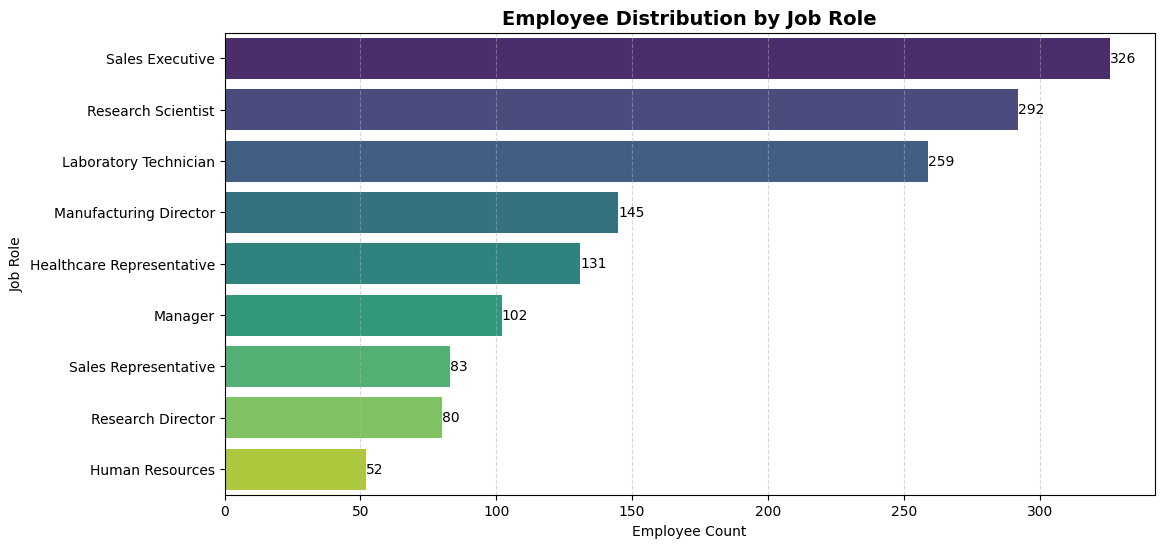

JobRole
Sales Executive              22.18
Research Scientist           19.86
Laboratory Technician        17.62
Manufacturing Director        9.86
Healthcare Representative     8.91
Manager                       6.94
Sales Representative          5.65
Research Director             5.44
Human Resources               3.54
Name: proportion, dtype: float64


In [ ]:
#Job Role Distribution
plt.figure(figsize=(12,6))

ax = sns.countplot(
    y='JobRole',
    data=df,
    order=df['JobRole'].value_counts().index,
    hue='JobRole',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Employee Distribution by Job Role", fontsize=14, fontweight='bold')
plt.xlabel("Employee Count")
plt.ylabel("Job Role")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

df["JobRole"].value_counts()

#job role percentage
jobrole_percentage = (df["JobRole"].value_counts(normalize=True) * 100).round(2)
print(jobrole_percentage)

**Observation**

- The organization has employees distributed across **nine different job roles**.
- **Sales Executive** is the largest job role with **326 employees**, followed by **Research Scientist (292)** and **Laboratory Technician (259)**.
- Mid-sized job roles include **Manufacturing Director (145)**, **Healthcare Representative (131)**, and **Manager (102)**.
- The least represented roles are **Sales Representative (83)**, **Research Director (80)**, and **Human Resources (52)**.
- The workforce distribution is uneven, with a significant concentration in customer-facing and research-oriented roles.

**Business Insight**

The organization employs a large number of Sales Executives, Research Scientists, and Laboratory Technicians, indicating that sales and research functions are core business operations. HR can use this information to prioritize recruitment, employee development, succession planning, and retention strategies for these critical roles. Roles with smaller employee counts may require focused succession planning to reduce operational risk.

**Conclusion**

Job role analysis shows that the workforce is concentrated in a few key operational roles, while several specialized positions have relatively fewer employees. These insights support strategic workforce planning and provide a foundation for analyzing attrition patterns across different job roles.

# **5.7 Education Level Distribution**
**Objective**

To analyze the educational qualifications of employees and understand the overall educational profile of the workforce.

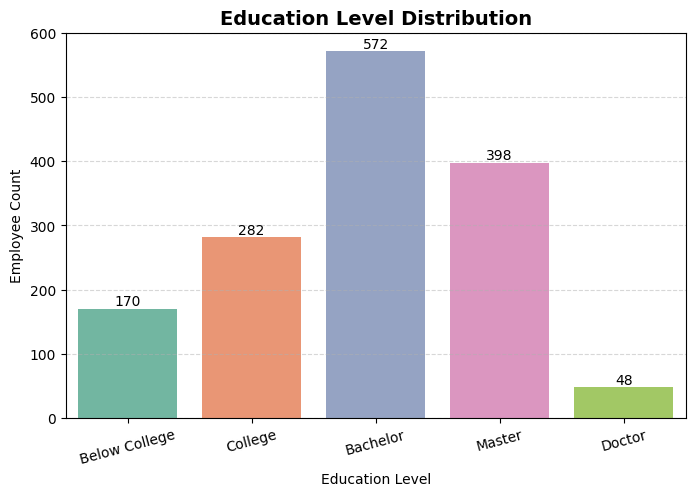

Education
1    11.56
2    19.18
3    38.91
4    27.07
5     3.27
Name: proportion, dtype: float64


In [ ]:
from matplotlib.colors import Normalize
#Education Level Distribution
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Education',
    data=df,
    order=sorted(df['Education'].unique()),
    hue='Education',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

# Replace numeric codes with labels
education_labels = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

plt.xticks(
    ticks=range(5),
    labels=[education_labels[i] for i in sorted(df['Education'].unique())],
    rotation=15
)

plt.title("Education Level Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Education Level")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

education_level_percentage=(df["Education"].value_counts(normalize=True)*100).round(2).sort_index()
print(education_level_percentage)

**Observation**

- Employees possess a wide range of educational qualifications, from **Below College** to **Doctorate** level.
- The majority of employees hold a **Bachelor's degree (572 employees)**, making it the most common qualification in the organization.
- **Master's degree holders (398 employees)** form the second-largest educational group.
- **College-level education (282 employees)** and **Below College education (170 employees)** have moderate representation.
- Employees with a **Doctorate degree (48 employees)** represent the smallest group within the workforce.

**Business Insight**

The workforce is primarily composed of employees with Bachelor's and Master's degrees, indicating a highly educated talent pool. This educational profile supports technical, research, and managerial roles within the organization. HR can use this information to design targeted learning programs, career development initiatives, and recruitment strategies aligned with organizational skill requirements.

**Conclusion**

The organization has a well-qualified workforce, with the majority of employees holding undergraduate and postgraduate degrees. This educational distribution provides a strong foundation for innovation, professional growth, and long-term organizational success.

#**5.8 Business Travel Distribution**
**Objective**

To analyze the frequency of business travel among employees and understand travel patterns within the organization.

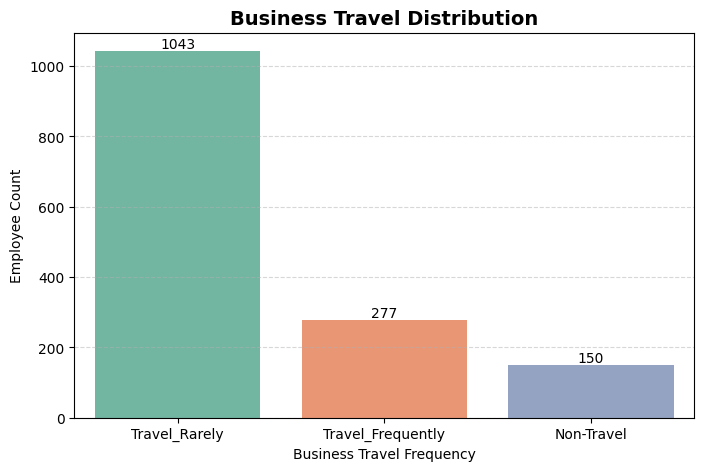

BusinessTravel
Travel_Rarely        70.95
Travel_Frequently    18.84
Non-Travel           10.20
Name: proportion, dtype: float64


In [ ]:
#Business Travel Distribution
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='BusinessTravel',
    data=df,
    order=df['BusinessTravel'].value_counts().index,
    hue='BusinessTravel',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Business Travel Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Business Travel Frequency")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

business_travel= (df["BusinessTravel"].value_counts(normalize=True)*100).round(2)
print(business_travel)

**Observation**

- Employees are classified into three business travel categories: **Travel_Rarely**, **Travel_Frequently**, and **Non-Travel**.
- The majority of employees (**1043 employees**) travel **rarely**, making it the most common travel category.
- **277 employees** travel frequently for business-related activities.
- Only **150 employees** do not travel as part of their job responsibilities.
- This indicates that most roles require occasional travel rather than frequent business trips.

**Business Insight**

Business travel patterns can significantly influence employee satisfaction, work-life balance, and attrition. Employees who travel frequently may experience higher stress levels, while employees who rarely travel may have more stable work routines. Further analysis of business travel against attrition can help HR determine whether travel frequency contributes to employee turnover.

**Conclusion**

The workforce is predominantly composed of employees who travel occasionally for business purposes. Understanding travel frequency enables HR to evaluate travel policies, employee well-being, and the potential impact of business travel on retention and productivity.

#**5.9 Overtime Distribution**
**Objective**

To analyze the distribution of employees who work overtime and understand the prevalence of overtime within the organization.

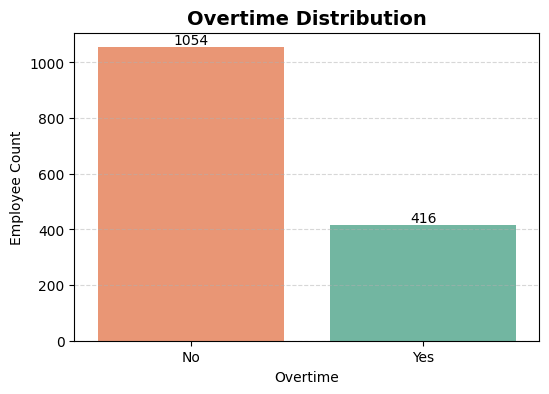

OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64


In [ ]:
#Overtime Distribution Analysis
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='OverTime',
    data=df,
    order=df['OverTime'].value_counts().index,
    hue='OverTime',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Overtime Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

overtime_percentage=(df["OverTime"].value_counts(normalize=True)*100).round(2)
print(overtime_percentage)

**Observation**

- Out of **1,470 employees**, **1,054 employees** do not work overtime, while **416 employees** work overtime.
- Approximately **71.7%** of employees do not work overtime, whereas **28.3%** perform overtime.
- The majority of the workforce follows regular working hours, while a considerable proportion of employees are engaged in overtime activities.

**Business Insight**

Overtime is an important workforce metric because excessive overtime can impact employee well-being, work-life balance, and job satisfaction. Employees working overtime may experience increased workload and stress, which can contribute to higher attrition. This variable will be further analyzed in the bivariate analysis by comparing overtime with employee attrition.

**Conclusion**

Most employees work within regular working hours; however, nearly one-third of the workforce performs overtime. Monitoring overtime patterns enables HR teams to evaluate workload distribution and develop strategies to improve employee well-being and retention.

# **5.10 Work-Life Balance Distribution**
**Objective**

To analyze employees' work-life balance ratings and understand how employees perceive the balance between their professional and personal lives.

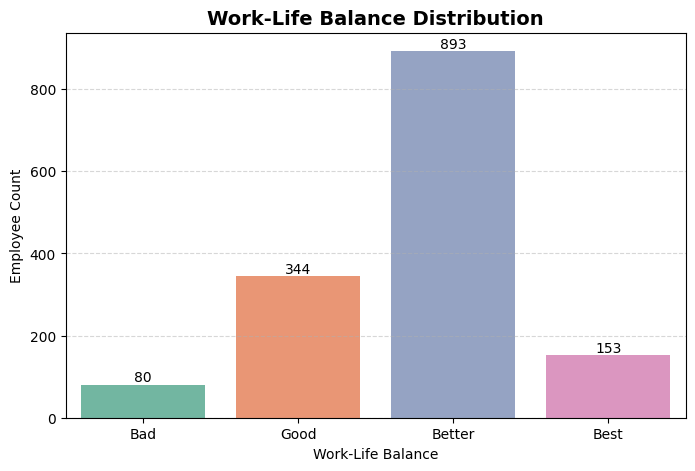

WorkLifeBalance
1     5.44
2    23.40
3    60.75
4    10.41
Name: proportion, dtype: float64


In [ ]:
#worklife balance analysis
plt.figure(figsize=(8,5))

labels = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

ax = sns.countplot(
    x='WorkLifeBalance',
    data=df,
    order=sorted(df['WorkLifeBalance'].unique()),
    hue='WorkLifeBalance',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['WorkLifeBalance'].unique())]
)

plt.title("Work-Life Balance Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Work-Life Balance")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#percentage
worklife_balance_percentage=(df["WorkLifeBalance"].value_counts(normalize=True)*100).round(2).sort_index()
print(worklife_balance_percentage)

**Observation**

- Employees rated their work-life balance across four categories: **Bad, Good, Better, and Best**.
- The majority of employees (**893 employees**) rated their work-life balance as **Better**, indicating that most employees perceive a satisfactory balance between work and personal life.
- **344 employees** rated their work-life balance as **Good**, while **153 employees** rated it as **Best**.
- Only **80 employees** reported a **Bad** work-life balance, representing the smallest group.

**Business Insight**

A positive work-life balance contributes to employee satisfaction, productivity, and retention. Since most employees reported a "Better" work-life balance, the organization appears to provide a supportive work environment. However, the employees reporting a poor work-life balance should be further analyzed, as they may be more susceptible to stress, burnout, and attrition.

**Conclusion**

The workforce generally reports a positive work-life balance, with the majority of employees rating it as "Better". These findings indicate a healthy organizational environment while highlighting the importance of supporting employees who experience poor work-life balance.

# **5.11 Monthly Income Distribution**

**Objective**

To analyze the distribution of employees' monthly income and identify salary patterns within the organization.

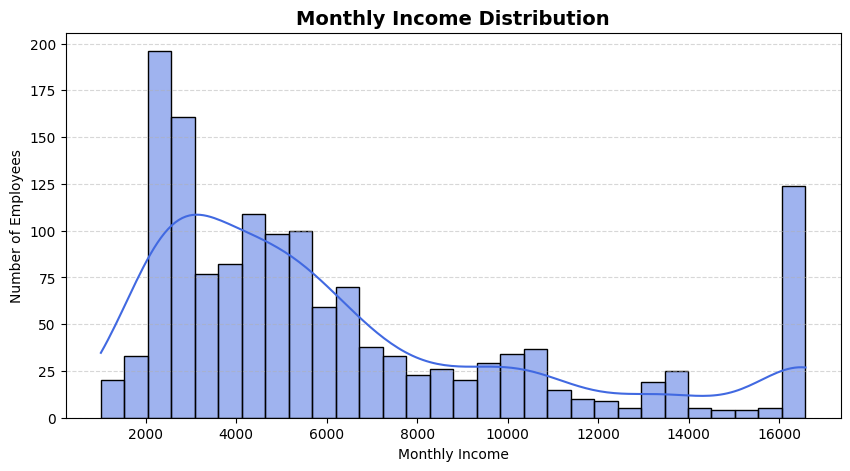

,MonthlyIncome
count,1470.000000
mean,6361.891837
std,4353.345470
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,16581.000000


In [ ]:
#analyze employee salary
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='MonthlyIncome',
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Monthly Income Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

df["MonthlyIncome"].describe()

In [ ]:
#Statistics
print(f"Average Monthly Income : {df['MonthlyIncome'].mean():.2f}")
print(f"Median Monthly Income  : {df['MonthlyIncome'].median():.2f}")
print(f"Minimum Monthly Income : {df['MonthlyIncome'].min()}")
print(f"Maximum Monthly Income : {df['MonthlyIncome'].max()}")

Average Monthly Income : 6361.89
Median Monthly Income  : 4919.00
Minimum Monthly Income : 1009
Maximum Monthly Income : 16581


**Observation**

- Employees' monthly income ranges from approximately **₹1,000 to ₹16,500**.
- The distribution is **positively (right) skewed**, indicating that most employees earn lower to mid-range salaries, while a smaller number receive higher salaries.
- A large concentration of employees falls between approximately **₹2,000 and ₹6,000** per month.
- The frequency of employees decreases as monthly income increases, with only a small proportion of employees earning salaries above **₹12,000**.
- The distribution suggests the presence of multiple salary bands, likely reflecting differences in job roles, experience levels, and organizational hierarchy.

**Business Insight**

Monthly income is an important workforce metric that influences employee motivation, job satisfaction, and retention. The concentration of employees in the lower and middle salary ranges suggests that compensation varies across different job roles and career levels. Further analysis of monthly income against attrition can help determine whether lower salary levels are associated with higher employee turnover.

**Conclusion**

The organization's salary structure is concentrated in the lower and middle income ranges, with fewer employees in higher salary brackets. These insights provide a foundation for analyzing compensation trends, employee satisfaction, and attrition risk.

# **5.12 Job Satisfaction Distribution**

**Objective**

To analyze employees' job satisfaction levels and understand overall employee satisfaction within the organization.

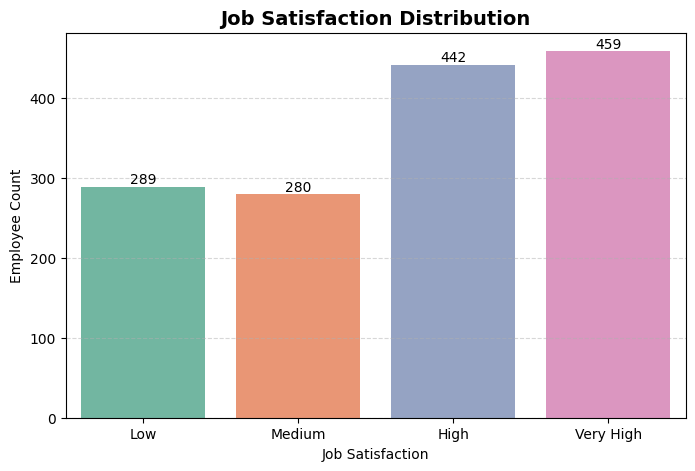

JobSatisfaction
1    19.66
2    19.05
3    30.07
4    31.22
Name: proportion, dtype: float64


In [ ]:
#job satisfaction analysis
plt.figure(figsize=(8,5))

labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

ax = sns.countplot(
    x='JobSatisfaction',
    data=df,
    order=sorted(df['JobSatisfaction'].unique()),
    hue='JobSatisfaction',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['JobSatisfaction'].unique())]
)

plt.title("Job Satisfaction Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Job Satisfaction")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#percentage of jobsatisfaction
job_satisfaction_percentage=(df["JobSatisfaction"].value_counts(normalize=True)*100).round(2).sort_index()
print(job_satisfaction_percentage)

**Observation**

- Employees rated their job satisfaction across four levels: **Low, Medium, High, and Very High**.
- The largest group of employees (**459 employees**) reported **Very High** job satisfaction.
- **442 employees** reported **High** job satisfaction.
- **289 employees** reported **Low** job satisfaction, while **280 employees** reported **Medium** job satisfaction.
- Overall, the majority of employees have **High or Very High** job satisfaction, indicating a generally positive perception of their jobs.

**Business Insight**

Job satisfaction is a key indicator of employee engagement and organizational performance. A workforce with high job satisfaction is generally more productive, motivated, and likely to remain with the organization. Employees reporting low satisfaction should be further analyzed alongside attrition, overtime, and work-life balance to identify factors affecting retention.

**Conclusion**

The organization demonstrates a positive job satisfaction profile, with most employees reporting High or Very High satisfaction. These findings suggest a healthy work environment while highlighting the importance of monitoring employees with lower satisfaction levels to reduce potential turnover.

#**5.13 Environment Satisfaction Distribution**

**Objective**

To analyze employees' satisfaction with their work environment and understand workplace conditions within the organization.

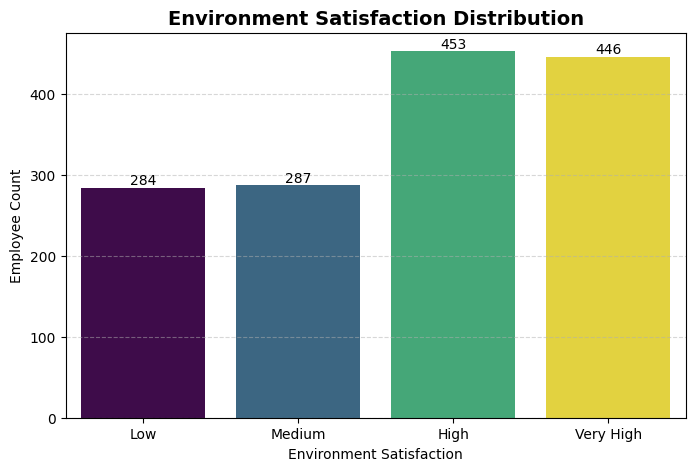

EnvironmentSatisfaction
1    19.32
2    19.52
3    30.82
4    30.34
Name: proportion, dtype: float64


In [ ]:
#Environment Satisfaction Analysis
plt.figure(figsize=(8,5))

labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

ax = sns.countplot(
    x='EnvironmentSatisfaction',
    data=df,
    order=sorted(df['EnvironmentSatisfaction'].unique()),
    hue='EnvironmentSatisfaction',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['EnvironmentSatisfaction'].unique())]
)

plt.title("Environment Satisfaction Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Environment Satisfaction")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

environment_satisfaction_percentage=(df["EnvironmentSatisfaction"].value_counts(normalize=True)*100).round(2).sort_index()
print(environment_satisfaction_percentage)

**Observation**

- Employees rated their work environment across four satisfaction levels: **Low, Medium, High, and Very High**.
- The largest group (**453 employees**) reported **High** environment satisfaction.
- **446 employees** reported **Very High** satisfaction with their work environment.
- **287 employees** reported **Medium** satisfaction, while **284 employees** reported **Low** satisfaction.
- Overall, the majority of employees expressed positive satisfaction with their work environment.

**Business Insight**

A positive work environment contributes significantly to employee engagement, productivity, and retention. Since most employees reported High or Very High environment satisfaction, the organization appears to provide a supportive workplace. Employees reporting Low satisfaction should be monitored further, as dissatisfaction with the work environment may contribute to reduced performance and increased attrition.

**Conclusion**

The organization maintains a generally positive work environment, with most employees expressing High or Very High satisfaction. These insights can help HR prioritize improvements for employees with lower satisfaction levels and strengthen workplace engagement initiatives.

# **6. Bivariate Analysis**
**Objective**

Bivariate Analysis is performed to examine the relationship between two variables. It helps identify factors influencing employee attrition, workforce performance, and employee engagement, enabling HR teams to make data-driven decisions.

#**6.1 Attrition vs Overtime**

**Objective**

To examine the relationship between overtime work and employee attrition and determine whether employees who work overtime are more likely to leave the organization.



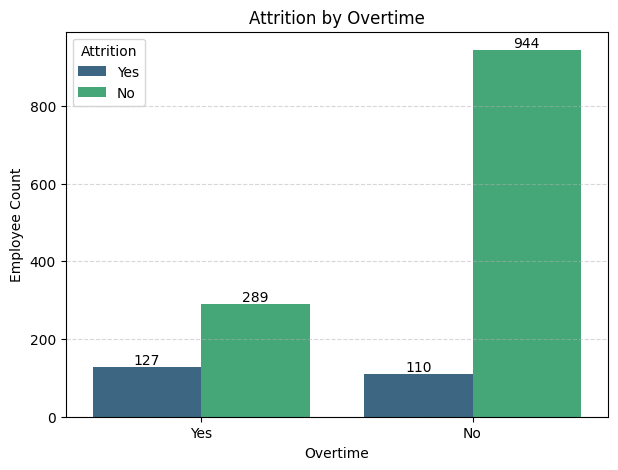

Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


In [ ]:
#analyze whether employees who work overtime are more likely to leave the organization.
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#percentage of attrition rate
attrition_rate = (
    pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
).round(2)

print(attrition_rate)

**Observation**

- Among employees who work overtime, **127 employees** left the
organization, while **289 employees** remained.
- Among employees who do not work overtime, only **110 employees** left, whereas **944 employees** remained.
- Although fewer employees work overtime overall, the proportion of employees leaving is noticeably higher among those who perform overtime.
- Employees who do not work overtime have a significantly higher retention rate.

**Business Insight**

The analysis suggests that overtime is strongly associated with employee attrition. Employees who frequently work overtime may experience increased workload, stress, and reduced work-life balance, making them more likely to leave the organization. HR departments should monitor overtime practices and implement workload management strategies to improve employee retention.

**Conclusion**

Overtime appears to be an important factor influencing employee attrition. Reducing excessive overtime, promoting work-life balance, and ensuring equitable workload distribution may help organizations improve employee satisfaction and reduce turnover.

# **6.2 Attrition vs Department**

**Objective**

To analyze employee attrition across different departments and identify departments with higher employee turnover.

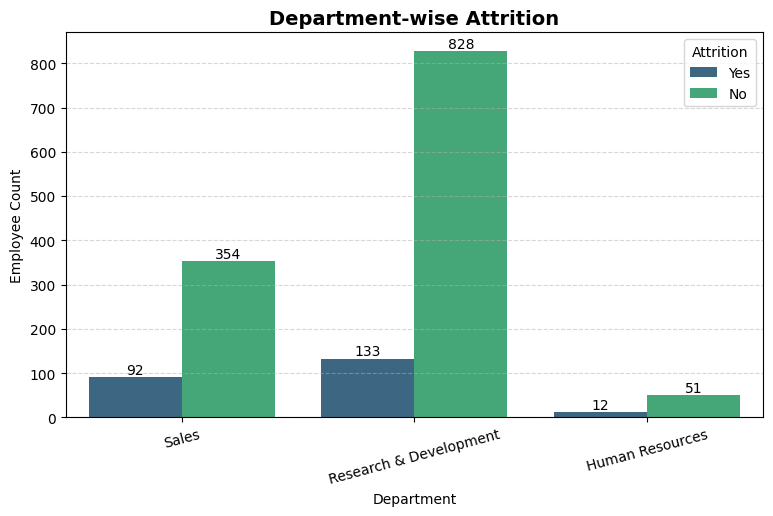

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


In [ ]:
#Analyze attrition vs department
plt.figure(figsize=(9,5))

ax = sns.countplot(
    x='Department',
    hue='Attrition',
    data=df,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Department-wise Attrition", fontsize=14, fontweight='bold')
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Crosstab
department_attrition = pd.crosstab(df['Department'], df['Attrition'])
print(department_attrition)


In [ ]:
#percentage Table
#Attrition percentage
print(" ")
print("Percentage")
department_attrition_rate = (
    pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
).round(2)

print(department_attrition_rate)

 
Percentage
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


**Observation**

- Employees from all three departments experienced attrition.
- The Research & Development department recorded the highest number of employees leaving (**133 employees**), followed by Sales (**92 employees**) and Human Resources (**12 employees**).
- The Research & Development department also has the largest workforce, which explains its higher number of attrition cases.
- Human Resources recorded the fewest attrition cases because it has the smallest workforce.

**Business Insight**

The absolute number of employees leaving is highest in the Research & Development department. However, HR should evaluate **attrition rates (%)** rather than raw counts to fairly compare departments of different sizes. Department-wise attrition analysis helps identify areas that may require targeted retention strategies, employee engagement initiatives, and workforce planning.

**Conclusion**

Employee turnover exists across all departments, with the highest number of attrition cases observed in Research & Development. Further evaluation using attrition percentages will provide a more accurate understanding of departmental attrition risk and support data-driven HR decision-making.

# **6.3 Attrition vs Business Travel**
**Objective**

To analyze the relationship between business travel frequency and employee attrition.

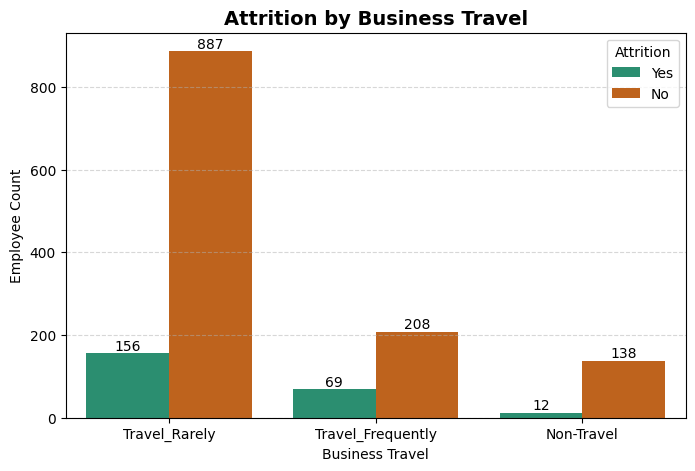

Attrition           No  Yes
BusinessTravel             
Non-Travel         138   12
Travel_Frequently  208   69
Travel_Rarely      887  156


In [ ]:
#attrition vs business travel
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='BusinessTravel',
    hue='Attrition',
    data=df,
    palette='Dark2'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Attrition by Business Travel", fontsize=14, fontweight='bold')
plt.xlabel("Business Travel")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

business_travel_attrition = pd.crosstab(df['BusinessTravel'], df['Attrition'])
print(business_travel_attrition)

In [ ]:
#percentage table
business_travel_attrition_rate = (
    pd.crosstab(
        df['BusinessTravel'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

print(business_travel_attrition_rate)

Attrition             No    Yes
BusinessTravel                 
Non-Travel         92.00   8.00
Travel_Frequently  75.09  24.91
Travel_Rarely      85.04  14.96


**Observation**

- Employees who **Travel Rarely** represent the largest workforce segment, with **156 employees leaving** and **887 employees remaining**.
- Among employees who **Travel Frequently**, **69 employees** left the organization, while **208 employees** remained.
- The **Non-Travel** category recorded the lowest attrition, with **12 employees leaving** and **138 employees remaining**.
- Although the highest number of attrition cases is observed in the **Travel Rarely** category, this group also has the largest number of employees. Therefore, the attrition rate (%) should be evaluated to fairly compare travel categories.

**Business Insight**

Business travel may influence employee satisfaction, work-life balance, and overall well-being. Employees who travel frequently may experience higher stress and work-related pressure, potentially increasing their likelihood of leaving the organization. Comparing attrition rates across travel categories enables HR teams to identify whether travel frequency is a significant contributor to employee turnover and to develop appropriate travel and employee support policies.

**Conclusion**

Employee attrition is observed across all business travel categories. Since the Travel Rarely group has the largest workforce, it also records the highest number of employees leaving. A percentage-based analysis is recommended to determine whether employees who travel frequently have a higher attrition risk than other groups.

# **6.4 Attrition vs Job Satisfaction**

**Objective**

To analyze the relationship between job satisfaction and employee attrition and determine whether employees with lower job satisfaction are more likely to leave the organization.

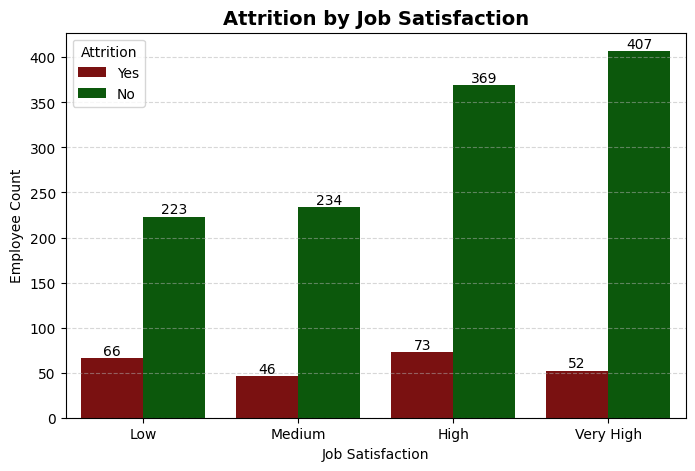

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [ ]:
#Attrition vs Job Satisfaction Analysis
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    hue_order=['Yes', 'No'],
    data=df,
    palette=['#8B0000', '#006400']
)

for container in ax.containers:
    ax.bar_label(container)

labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['JobSatisfaction'].unique())]
)

plt.title("Attrition by Job Satisfaction", fontsize=14, fontweight='bold')
plt.xlabel("Job Satisfaction")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

pd.crosstab(df['JobSatisfaction'], df['Attrition'])

In [ ]:
#percentage table
job_satisfaction_rate = (
    pd.crosstab(
        df['JobSatisfaction'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

print(job_satisfaction_rate)

Attrition           No    Yes
JobSatisfaction              
1                77.16  22.84
2                83.57  16.43
3                83.48  16.52
4                88.67  11.33


**Observation**

- Employees with **Low** job satisfaction recorded **66 attrition cases**, while **223 employees** remained in the organization.
- Employees with **Medium** job satisfaction recorded **46 attrition cases** and **234 employees** remained.
- The **High** satisfaction group had **73 employees** leave and **369 employees** stay.
- The **Very High** satisfaction group recorded **52 attrition cases**, while **407 employees** remained.
- Although the **High** satisfaction category shows the highest number of employees leaving in absolute terms, it also contains a larger workforce. Therefore, attrition percentages should be used for a fair comparison across satisfaction levels.

**Business Insight**

Job satisfaction is an important indicator of employee engagement and retention. Employees with lower satisfaction levels may be more likely to leave due to reduced motivation or workplace dissatisfaction. Monitoring satisfaction levels enables HR teams to identify at-risk employees and implement engagement, recognition, and career development programs to improve retention.

**Conclusion**

Employee attrition occurs across all job satisfaction levels. While the absolute number of employees leaving varies among categories, percentage-based analysis is recommended to accurately assess the relationship between job satisfaction and attrition. Improving employee satisfaction can contribute to stronger retention and organizational performance.

#**6.5 Attrition vs Work-Life Balance**

**Objective**

To analyze the relationship between employees' work-life balance and attrition, and identify whether poor work-life balance contributes to employee turnover.

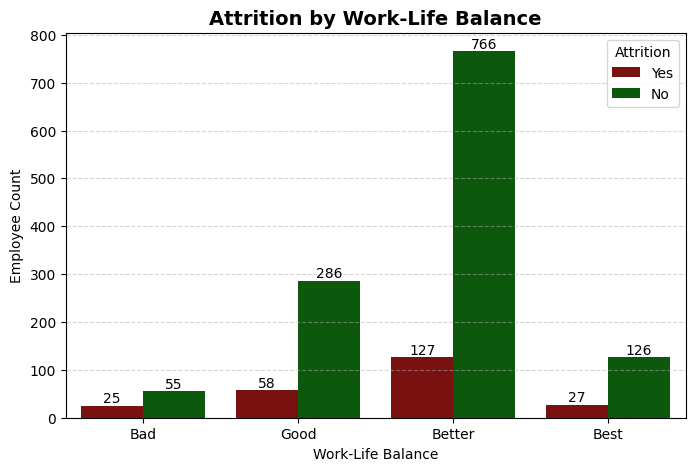

Attrition,No,Yes
Bad,55,25
Good,286,58
Better,766,127
Best,126,27


In [ ]:
#Attrition vs Work-Life Balance Analysis
plt.figure(figsize=(8,5))

labels = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

ax = sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    hue_order=['Yes', 'No'],
    data=df,
    palette=['#8B0000', '#006400']
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['WorkLifeBalance'].unique())]
)

plt.title("Attrition by Work-Life Balance", fontsize=14, fontweight='bold')
plt.xlabel("Work-Life Balance")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#count table
wlb_table = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition']
)

wlb_table.index = [
    "Bad",
    "Good",
    "Better",
    "Best"
]

display(wlb_table)

In [ ]:
#percentage of worklife balance
wlb_rate = (
    pd.crosstab(
        df['WorkLifeBalance'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

wlb_rate.index = [
    "Bad",
    "Good",
    "Better",
    "Best"
]

display(wlb_rate)

Attrition,No,Yes
Bad,68.75,31.25
Good,83.14,16.86
Better,85.78,14.22
Best,82.35,17.65


**Observation**

- Employees with **Bad** work-life balance recorded **25 attrition cases**, while **55 employees** remained in the organization.
- Employees with **Good** work-life balance recorded **58 attrition cases**, whereas **286 employees** remained.
- The **Better** work-life balance category had the highest number of employees, with **127 attrition cases** and **766 retained employees**.
- Employees with **Best** work-life balance recorded **27 attrition cases**, while **126 employees** remained.
- Although the **Better** category has the highest number of employees leaving, it also represents the largest workforce group. Therefore, attrition percentages should be used for an accurate comparison across work-life balance levels.

**Business Insight**

Work-life balance is an important factor affecting employee satisfaction and retention. Employees experiencing poor work-life balance may be more susceptible to stress and burnout, increasing the likelihood of leaving the organization. By monitoring work-life balance trends, HR teams can implement flexible work arrangements, wellness initiatives, and workload optimization strategies to improve employee well-being and reduce attrition.

**Conclusion**

Employee attrition is observed across all work-life balance categories. While the highest number of attrition cases occurs in the Better category due to its larger workforce, percentage-based analysis provides a more reliable measure of attrition risk. Promoting a healthy work-life balance can contribute to improved employee engagement and long-term retention.

#**6.6 Attrition vs Monthly Income**

**Objective**

To analyze the relationship between employees' monthly income and attrition, and determine whether compensation influences employee retention.

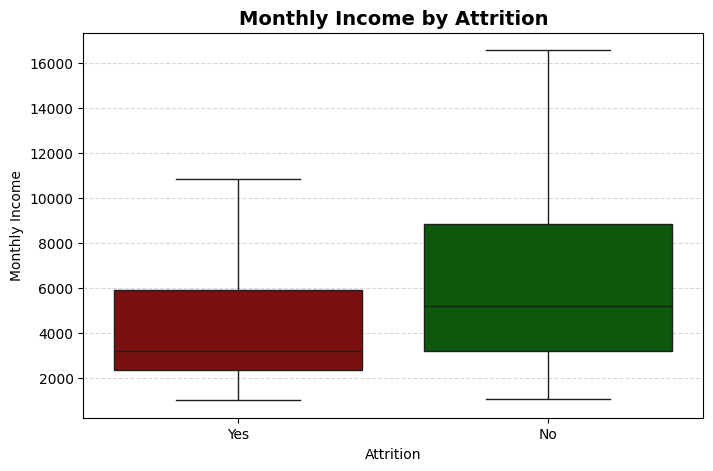

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6676.280616,4444.822596,1051.0,3211.0,5204.0,8834.0,16581.0
Yes,237.0,4726.274262,3409.904624,1009.0,2373.0,3202.0,5916.0,16581.0


In [ ]:
#Attrition vs Monthly Income Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df,
    hue='Attrition',
    palette=['#8B0000', '#006400'],
    legend=False,
    showfliers=False
)

plt.title("Monthly Income by Attrition", fontsize=14, fontweight='bold')
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

df.groupby('Attrition')['MonthlyIncome'].describe()

**Observation**

- Employees who left the organization generally have a **lower median monthly income** compared to employees who remained.
- The median monthly income for employees who stayed is noticeably higher, indicating that retained employees tend to earn more.
- The salary distribution of employees who stayed is wider, reflecting greater variation in income across different job roles and experience levels.
- A few high-income outliers are present in both groups, indicating that some highly paid employees also left the organization.
- Overall, employees with lower monthly income appear to have a greater tendency to leave the organization.

**Business Insight**

Compensation is an important factor influencing employee retention. The analysis suggests that employees earning lower salaries may be more likely to leave the organization, possibly due to better external opportunities, limited financial growth, or dissatisfaction with compensation. HR teams can use this insight to review salary structures, benchmark compensation, and develop retention strategies for employees in lower income ranges.

**Conclusion**

Monthly income appears to have a meaningful relationship with employee attrition. Employees with lower salaries show a greater tendency to leave the organization, while higher-income employees generally demonstrate better retention. Compensation analysis should be incorporated into workforce planning and attrition prediction models.

#**6.7 Attrition vs Age**

**Objective**

To analyze the relationship between employees' age and attrition and determine whether age influences employee retention.

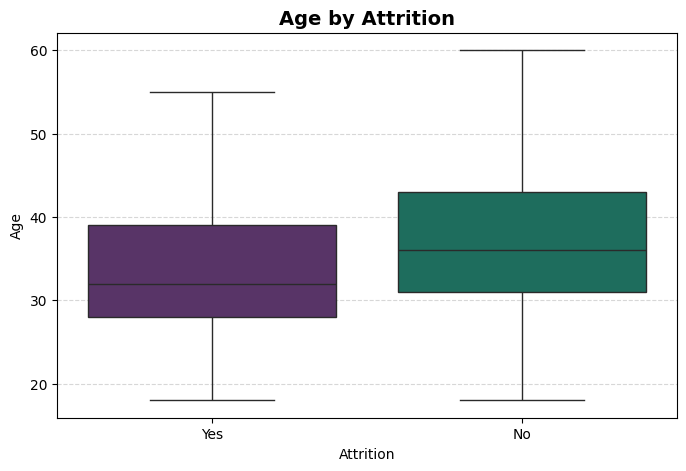

In [ ]:
#Attrition vs Age Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Age',
    data=df,
    hue='Attrition',
    palette=['#5B2C6F', '#117A65'],   # Purple & Teal
    legend=False,
    showfliers=False
)

plt.title("Age by Attrition", fontsize=14, fontweight='bold')
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
#statistical summary
age_summary = df.groupby('Attrition')['Age'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
)

display(age_summary)

,count,mean,median,min,max,std
Attrition,,,,,,
No,1233,37.561233,36.0,18,60,8.88836
Yes,237,33.607595,32.0,18,58,9.68935


**Observation**

- Employees who left the organization have a **lower median age** than employees who remained.
- The median age of employees with attrition is approximately **32 years**, whereas employees who stayed have a median age of around **36 years**.
- The age distribution of employees who stayed is slightly wider, indicating greater variation in employee age.
- Younger employees appear to leave the organization more frequently than older employees.
- Both groups cover a broad age range, suggesting that attrition occurs across different age groups, although it is more concentrated among relatively younger employees.

**Business Insight**

Age appears to be an influential factor in employee attrition. Younger employees may be more likely to seek career growth opportunities, higher compensation, or new challenges, resulting in increased turnover. Organizations should focus on career development, mentorship programs, and growth opportunities for early-career employees to improve retention.

**Conclusion**

The analysis indicates that employees who leave the organization tend to be younger than those who remain. Age should therefore be considered an important feature in employee attrition prediction models and workforce planning strategies.

#**6.8 Attrition vs Gender**

**Objective**

To analyze the relationship between employee gender and attrition and determine whether attrition varies between male and female employees.

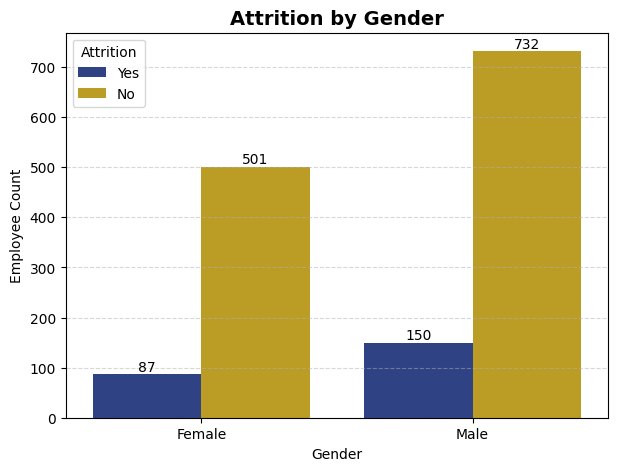

In [ ]:
#Attrition vs Gender Analysis
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='Gender',
    hue='Attrition',
    data=df,
    hue_order=['Yes', 'No'],
    palette=['#1F3A93', '#D4AC0D']
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Attrition by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
#count table
gender_table = pd.crosstab(
    df['Gender'],
    df['Attrition']
)

display(gender_table)

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


In [ ]:
#percentage
gender_rate = (pd.crosstab(df['Gender'],df['Attrition'],normalize='index') * 100).round(2)

display(gender_rate)

Attrition,No,Yes
Gender,,
Female,85.20,14.80
Male,82.99,17.01


**Observation**

- Both male and female employees experienced attrition during the analysis period.
- Among female employees, **87 employees** left the organization, while **501 employees** remained.
- Among male employees, **150 employees** left the organization, whereas **732 employees** remained.
- The number of attrition cases is higher among male employees; however, the organization also employs more male employees than female employees.
- Therefore, attrition percentages should be considered to determine whether gender has a significant influence on employee turnover.

**Business Insight**

Gender-wise attrition analysis helps organizations evaluate whether employee retention differs across workforce groups. While more male employees left the organization in absolute numbers, this may be influenced by the larger male workforce. HR teams should compare attrition rates rather than raw counts to identify whether gender-specific retention initiatives are required.

**Conclusion**

Employee attrition is observed among both male and female employees. Based on the current analysis, gender alone does not provide sufficient evidence of higher attrition risk. Percentage-based analysis should be used alongside other workforce factors to accurately assess the impact of gender on employee retention.

#**6.9 Correlation Analysis**

**Objective**

To identify relationships between numerical features and understand how different employee attributes are correlated with each other, supporting feature selection and workforce analytics.

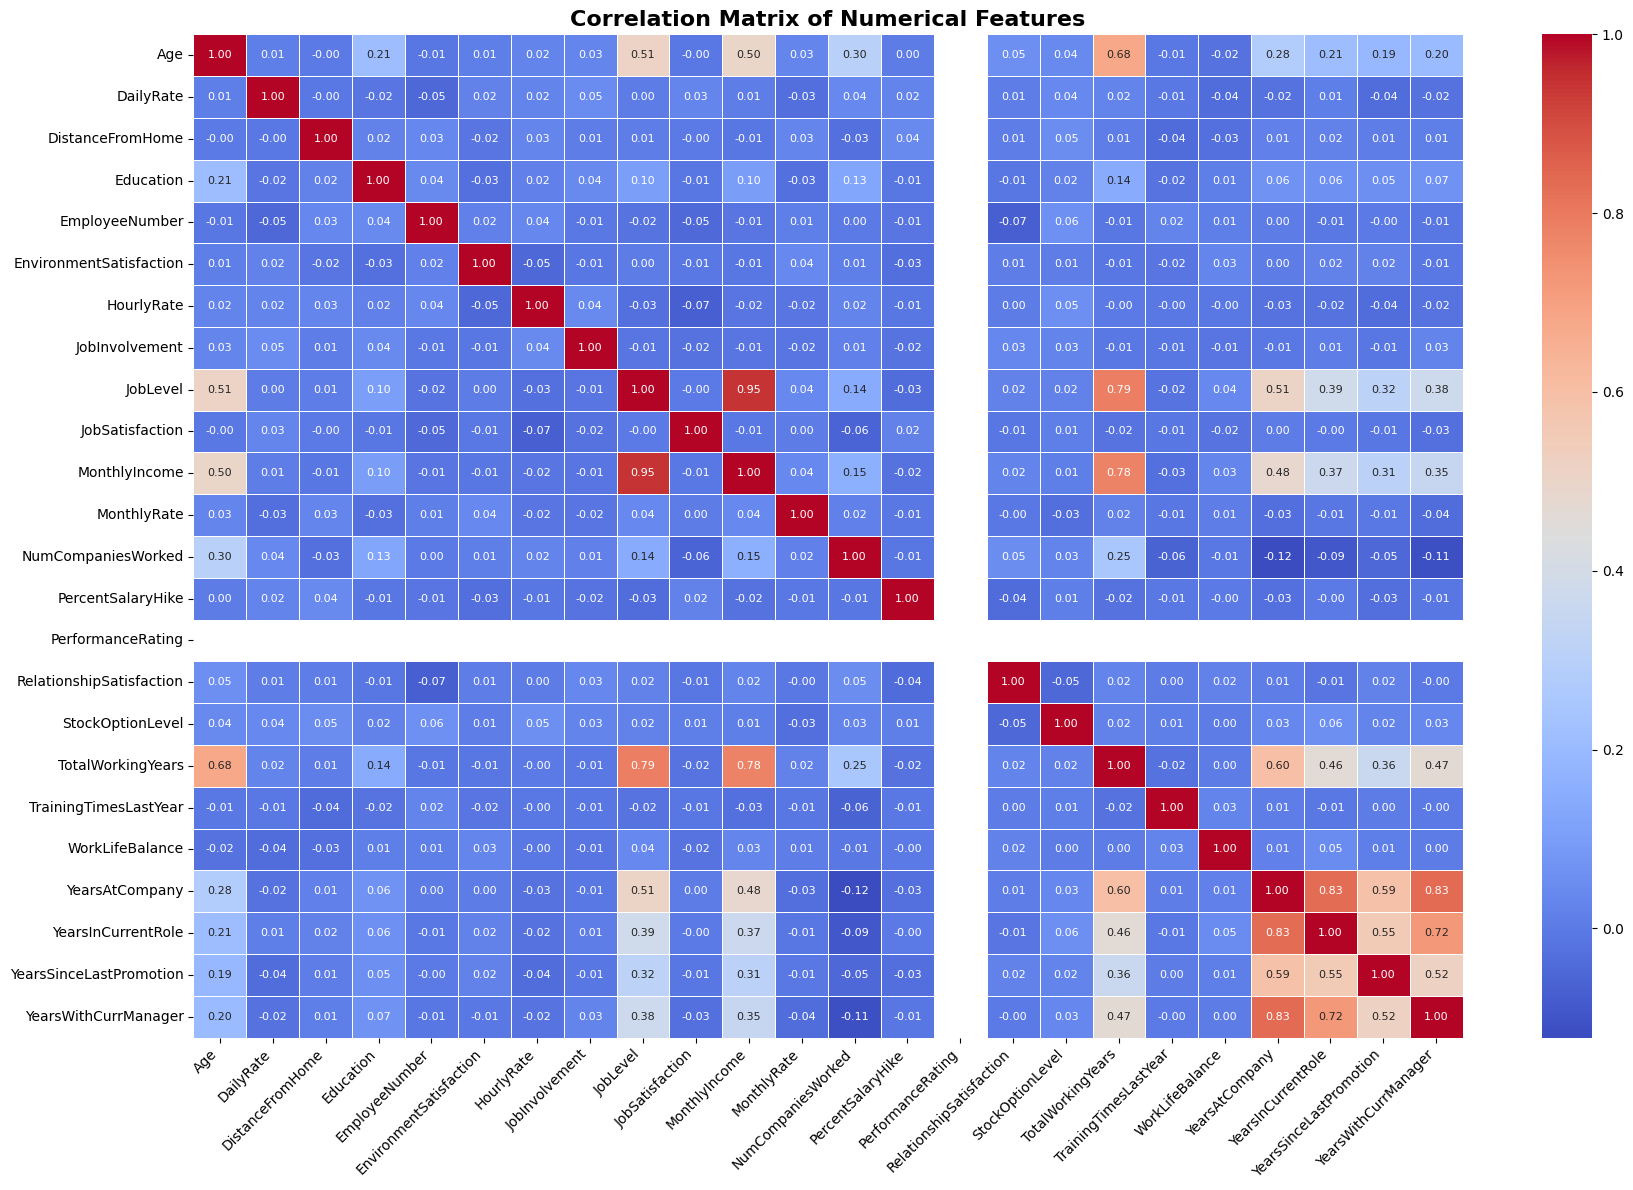

In [ ]:
#correlation matrix
plt.figure(figsize=(18,12))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.title("Correlation Matrix of Numerical Features",
          fontsize=16,
          fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#Top Correlated Features
corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs.sort_values(
    ascending=False,
    key=abs
)

corr_pairs = corr_pairs[
    corr_pairs != 1
]

corr_pairs.head(20)

MonthlyIncome            JobLevel                   0.945557
JobLevel                 MonthlyIncome              0.945557
YearsWithCurrManager     YearsAtCompany             0.833621
YearsAtCompany           YearsWithCurrManager       0.833621
                         YearsInCurrentRole         0.829616
YearsInCurrentRole       YearsAtCompany             0.829616
TotalWorkingYears        JobLevel                   0.786734
JobLevel                 TotalWorkingYears          0.786734
MonthlyIncome            TotalWorkingYears          0.776481
TotalWorkingYears        MonthlyIncome              0.776481
YearsInCurrentRole       YearsWithCurrManager       0.723496
YearsWithCurrManager     YearsInCurrentRole         0.723496
TotalWorkingYears        Age                        0.678402
Age                      TotalWorkingYears          0.678402
YearsAtCompany           TotalWorkingYears          0.597323
TotalWorkingYears        YearsAtCompany             0.597323
YearsAtCompany           YearsSinceLastPromotion    0.589700
YearsSinceLastPromotion  YearsAtCompany             0.589700
                         YearsInCurrentRole         0.550005
YearsInCurrentRole       YearsSinceLastPromotion    0.550005
dtype: float64

**Observation**

- Most numerical features exhibit weak to moderate correlations, indicating that each feature contributes unique information to the dataset.
- A very strong positive correlation (**0.95**) exists between **Job Level** and **Monthly Income**, indicating that employees at higher job levels generally receive higher salaries.
- **Total Working Years** shows strong positive correlations with **Job Level (0.79)** and **Monthly Income (0.78)**, suggesting that experienced employees tend to hold senior positions and earn higher salaries.
- **Years at Company** has a strong positive relationship with **Years in Current Role (0.83)** and **Years with Current Manager (0.83)**, indicating that employees who stay longer in the organization generally remain in the same role and work with the same manager for extended periods.
- **Age** has a moderate positive correlation with **Total Working Years (0.68)**, reflecting that older employees generally possess more work experience.
- Satisfaction-related variables, including **Job Satisfaction**, **Environment Satisfaction**, **Relationship Satisfaction**, and **Work-Life Balance**, exhibit weak correlations with other numerical features, suggesting they independently influence employee behavior.
- No significant negative correlations are observed among the numerical variables.





**Business Insight**

Correlation analysis reveals that employee experience, job level, and compensation are closely related. As employees gain experience, they are more likely to receive promotions and higher salaries. Conversely, satisfaction-related variables show relatively weak correlations with other numerical features, highlighting that employee satisfaction depends on multiple independent workplace factors. These insights are valuable for feature selection in predictive models and support AI-driven workforce analytics.

**Conclusion**

The correlation matrix demonstrates that the dataset has limited multicollinearity, with only a few expected strong relationships among experience, job level, and salary-related variables. Overall, the numerical features provide diverse and meaningful information, making the dataset suitable for predictive modeling, workforce analytics, and employee attrition prediction.

#**Strongest Positive Correlations**


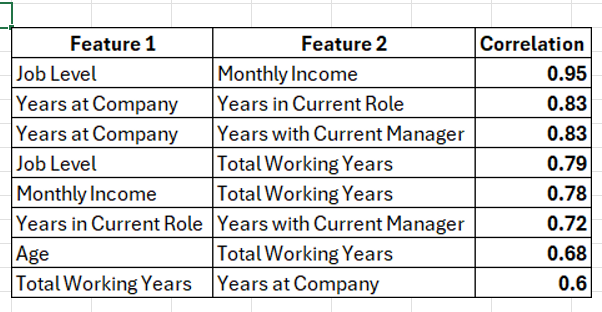

# **6.10 Final Findings**

## Key Insights & Findings

1. The dataset is clean, complete, and ready for predictive modeling after handling missing values, duplicates, and outliers.

2. Employee attrition is imbalanced, with significantly more employees staying than leaving the organization.

3. Employees working overtime exhibit a higher likelihood of attrition compared to employees who do not work overtime.

4. Employees with lower monthly income tend to leave the organization more frequently than higher-income employees.

5. Younger employees show relatively higher attrition compared to older employees, indicating that early-career employees may require stronger retention initiatives.

6. Research & Development contains the largest workforce and consequently records the highest number of employee exits.

7. Job satisfaction and work-life balance influence employee retention and should be considered important predictive features.

8. Business travel frequency may contribute to employee turnover and should be evaluated in workforce planning.

9. Employee experience strongly influences job level and salary, as demonstrated by the high correlations among Total Working Years, Job Level, and Monthly Income.

10. The dataset contains meaningful workforce patterns and is well suited for developing AI-based attrition prediction models and workforce intelligence dashboards.

# **Exploratory Data Analysis Summary**

Exploratory Data Analysis (EDA) was performed to understand workforce characteristics, identify data quality issues, and discover factors influencing employee attrition.

The analysis included data cleaning, summary statistics, missing value analysis, outlier treatment, univariate analysis, bivariate analysis, and correlation analysis. Various workforce attributes such as age, department, gender, business travel, overtime, job satisfaction, work-life balance, monthly income, and experience were explored to identify meaningful trends and relationships.

The findings indicate that employee attrition is influenced by multiple factors, including overtime, compensation, work-life balance, job satisfaction, age, and employee experience. Strong relationships were observed among experience, job level, and salary, while satisfaction-related variables showed relatively independent behavior.

These insights establish a strong foundation for the next phase of the project, where machine learning models will be developed to predict employee attrition and generate AI-powered workforce intelligence for strategic HR decision-making.

# **Conclusion**

This notebook successfully completed data cleaning and exploratory data analysis for the AI-Powered Workforce Analytics & Talent Intelligence Dashboard project.

The dataset was cleaned by handling data quality issues, removing unnecessary attributes, and treating outliers. Exploratory Data Analysis revealed important workforce patterns related to employee attrition, compensation, work-life balance, overtime, job satisfaction, age, and employee experience.

The cleaned dataset and analytical insights generated in this notebook will be used in the next phase of the project to develop AI-powered predictive models for employee attrition and workforce intelligence.

#**Opportunities**

- Improve employee retention through better work-life balance initiatives.
- Develop career growth programs for younger employees.
- Enhance employee engagement and recognition programs.
- Optimize compensation strategies for lower-income employees.
- Strengthen workforce planning using predictive analytics.

#**Risks**

- High overtime may increase employee burnout and attrition.
- Lower employee satisfaction may reduce organizational productivity.
- Salary disparities may contribute to employee turnover.
- Business travel requirements may negatively impact retention.
- Younger employees may leave for better career opportunities.

# **Recommendations**

- Monitor employee attrition continuously using predictive models.
- Implement early warning systems for high-risk employees.
- Review overtime policies and workload distribution.
- Conduct regular employee satisfaction surveys.
- Invest in learning, development, and career progression programs.